# Pairwise Jaccard Interaction Analysis: V7 vs V12

**What this notebook does:**
- Loads per-frame H-bond interaction tables for V7 and V12 simulations
- Filters to **high-variance bonds** (|Δfreq| ≥ 20 % between Phase 1 and Phase 2)
- Computes a **Jaccard distance matrix** (V7×V7, V7×V12, V12×V7, V12×V12)
- Visualises the combined Jaccard matrix as a heat-map
- Performs **hierarchical clustering** on the full matrix and on a
  **transition-state window** (±36 frames around each phase boundary)
- Trains a **Decision Tree** to predict Phase 1 vs Phase 2 from the interaction profile

**Sections:**
1. Install & import libraries
2. Configuration (paths, phase limits, interaction files)
3. Helper functions
4. Load interaction data and filter high-variance bonds
5. Compute Jaccard distance matrices
6. Plot Jaccard heat-map
7. Hierarchical clustering — full matrix
8. Hierarchical clustering — transition-state window
9. Decision Tree classifier


In [ ]:
# 1. Install required libraries
!pip install MDAnalysis
!pip install MDAnalysisTests

In [1]:
# 2. Imports
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

from sklearn.metrics import pairwise_distances
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

from scipy.cluster.hierarchy import linkage, dendrogram


from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# 3. Configuration
ROOTDIR    = '/content/drive/MyDrive/M1_STAGE/Data/interactions/'
OUTPUT_DIR = '/content/drive/MyDrive/M1_STAGE/Manips/Tables/'

INTERACTION_FILES = ['res_V12.csv', 'res_V7.csv']
SIMULATION_NAMES  = ['V12', 'V7']

PHASE_LIMITS = {'V12': 35, 'V7': 198}

# Transition-state window (frames around phase boundary to include)
SELECTED_FRAMES = {
    'V12': range(0,   72),
    'V7':  range(163, 235),
}
PHASES_ORDERED  = ['V12_ph1', 'V12_ph2', 'V7_ph1', 'V7_ph2']

# Minimum |Δfreq| to consider a bond 'high-variance'
MIN_DELTA_PCT = 20

COLOR_MAP = {
    'V7_Phase1':  '#FF9F43',
    'V7_Phase2':  '#EE5253',
    'V12_Phase1': '#0ABDE3',
    'V12_Phase2': '#10AC84',
}

os.chdir(ROOTDIR)

In [3]:
# 4. Helper functions

def find_hbonds(df: pd.DataFrame) -> list:
    return [c for c in df.columns if 'hb' in c]


def phase_frequency(df_phase: pd.DataFrame, hbond_cols: list) -> dict:
    n = len(df_phase)
    return {col: (df_phase[col] > 0).sum() / n * 100
            for col in hbond_cols if col in df_phase.columns and n > 0}


def split_phases(df_ts: pd.DataFrame, sim_name: str):
    lim = PHASE_LIMITS[sim_name]
    idx = df_ts.index
    ph1 = df_ts.loc[idx[idx <= lim]] if (idx <= lim).any() else pd.DataFrame(columns=df_ts.columns)
    ph2 = df_ts.loc[idx[idx >  lim]] if (idx >  lim).any() else pd.DataFrame(columns=df_ts.columns)
    return ph1, ph2


def high_variance_bonds(freq_table: pd.DataFrame, min_delta: float = MIN_DELTA_PCT) -> pd.DataFrame:
    sim_names = list({c.rsplit('_', 1)[0] for c in freq_table.columns})
    max_delta = pd.Series(0.0, index=freq_table.index)
    for sim in sim_names:
        ph1, ph2 = f'{sim}_ph1', f'{sim}_ph2'
        if ph1 in freq_table.columns and ph2 in freq_table.columns:
            max_delta = max_delta.combine((freq_table[ph2] - freq_table[ph1]).abs(), max)
    return freq_table[max_delta >= min_delta]


def get_phase_key(abs_idx: int, n_v7: int = 1001) -> str:
    if abs_idx < n_v7:
        return 'V7_Phase1' if abs_idx <= PHASE_LIMITS['V7'] else 'V7_Phase2'
    local = abs_idx - n_v7
    return 'V12_Phase1' if local <= PHASE_LIMITS['V12'] else 'V12_Phase2'

In [4]:
# 5. Load interaction data
for sim_file, sim_name in zip(INTERACTION_FILES, SIMULATION_NAMES):
    df = pd.read_csv(sim_file)
    globals()[f'{sim_name}_df'] = df
    print(f'{sim_name}: {len(df)} frames, {len(find_hbonds(df))} H-bonds')

V12: 1001 frames, 1741 H-bonds
V7: 1001 frames, 1741 H-bonds


In [5]:
# 6. Build frequency table and identify high-variance bonds
all_phase_freqs = {}
hbonds_all = find_hbonds(pd.concat([V12_df, V7_df]))

for sim_name in SIMULATION_NAMES:
    df = globals()[f'{sim_name}_df']
    df = df.loc[:, df.sum(axis=0) > 0]                    # drop always-absent
    df = df.loc[:, df.sum(axis=0) != len(df)]              # drop always-present
    df_ts = df.loc[df.index.isin(SELECTED_FRAMES[sim_name])]
    ph1, ph2 = split_phases(df_ts, sim_name)
    hbonds = find_hbonds(df_ts)
    all_phase_freqs[f'{sim_name}_ph1'] = phase_frequency(ph1, hbonds)
    all_phase_freqs[f'{sim_name}_ph2'] = phase_frequency(ph2, hbonds)
    globals()[f'{sim_name}_df_ts'] = df_ts

freq_table = pd.DataFrame(all_phase_freqs)
existing   = [c for c in PHASES_ORDERED if c in freq_table.columns]
freq_table = freq_table[existing].fillna(0)

hv_freq     = high_variance_bonds(freq_table, min_delta=MIN_DELTA_PCT)
hv_cols     = list(hv_freq.index)
print(f'High-variance bonds: {len(hv_cols)}')

# Filter full simulation DataFrames to high-variance bonds
for sim_name in SIMULATION_NAMES:
    df_filtered = globals()[f'{sim_name}_df'][hv_cols]
    globals()[f'{sim_name}_df'] = df_filtered

High-variance bonds: 98


In [6]:
# 7. Compute Jaccard distance matrices
arr_V7  = V7_df.to_numpy()
arr_V12 = V12_df.to_numpy()

jac_V7_V7   = pd.DataFrame(pairwise_distances(arr_V7,  arr_V7,  metric='jaccard', n_jobs=-1))
jac_V7_V12  = pd.DataFrame(pairwise_distances(arr_V7,  arr_V12, metric='jaccard', n_jobs=-1))
jac_V12_V7  = pd.DataFrame(pairwise_distances(arr_V12, arr_V7,  metric='jaccard', n_jobs=-1))
jac_V12_V12 = pd.DataFrame(pairwise_distances(arr_V12, arr_V12, metric='jaccard', n_jobs=-1))

jac_full = pd.concat([
    pd.concat([jac_V7_V7, jac_V12_V7], ignore_index=True),
    pd.concat([jac_V7_V12, jac_V12_V12], ignore_index=True)
], axis=1, ignore_index=True).fillna(0)

print(f'Jaccard matrix shape: {jac_full.shape}')

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/pairwise.py:2466: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/pairwise.py:2466: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/pairwise.py:2466: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/pairwise.py:2466: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


Jaccard matrix shape: (2002, 2002)


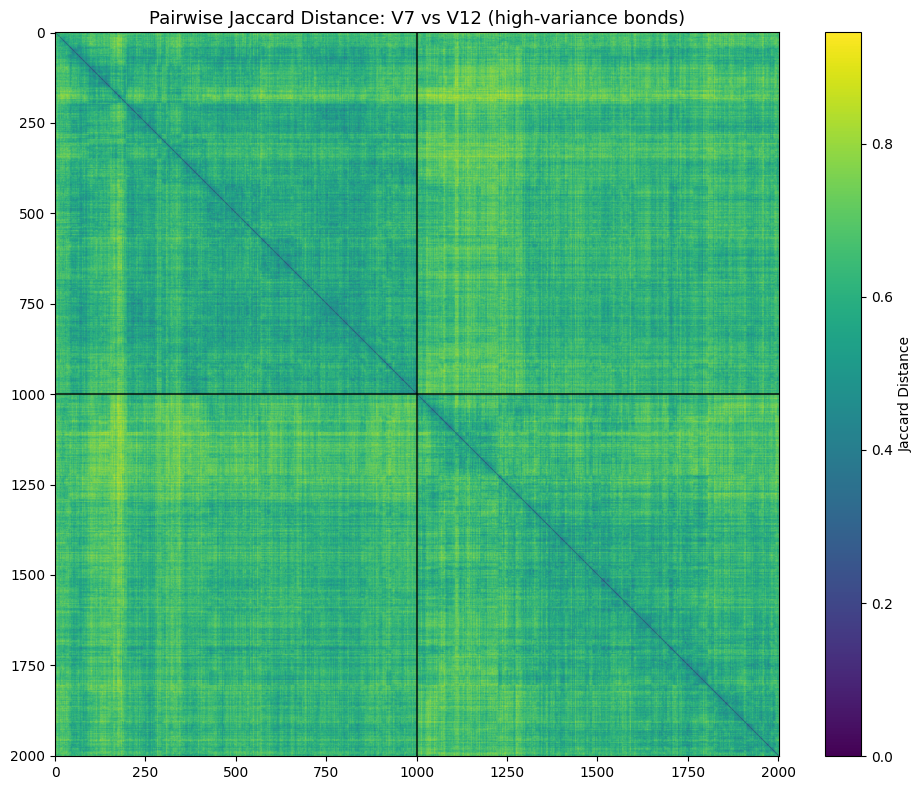

In [7]:
# 8. Plot Jaccard heat-map
n_v7 = len(V7_df)
fig  = plt.figure(figsize=(10, 8))
plt.imshow(jac_full, cmap='viridis', origin='upper')
plt.axvline(x=n_v7, color='black', linewidth=1.5, alpha=0.7)
plt.axhline(y=n_v7, color='black', linewidth=1.5, alpha=0.7)
plt.colorbar(label='Jaccard Distance')
plt.title('Pairwise Jaccard Distance: V7 vs V12 (high-variance bonds)', fontsize=13)
plt.tight_layout()
plt.show()

In [8]:
# 9. Save Jaccard matrices
jac_V7_V7.to_csv(  os.path.join(OUTPUT_DIR, 'jaccard_V7_V7.csv'),   index=False)
jac_V7_V12.to_csv( os.path.join(OUTPUT_DIR, 'jaccard_V7_V12.csv'),  index=False)
jac_V12_V7.to_csv( os.path.join(OUTPUT_DIR, 'jaccard_V12_V7.csv'),  index=False)
jac_V12_V12.to_csv(os.path.join(OUTPUT_DIR, 'jaccard_V12_V12.csv'), index=False)
jac_full.to_csv(   os.path.join(OUTPUT_DIR, 'jaccard_full.csv'),     index=False)
print('Saved.')

Saved.


/tmp/ipykernel_14072/3750273351.py:2: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  complete_clustering = linkage(jac_full, method='ward')


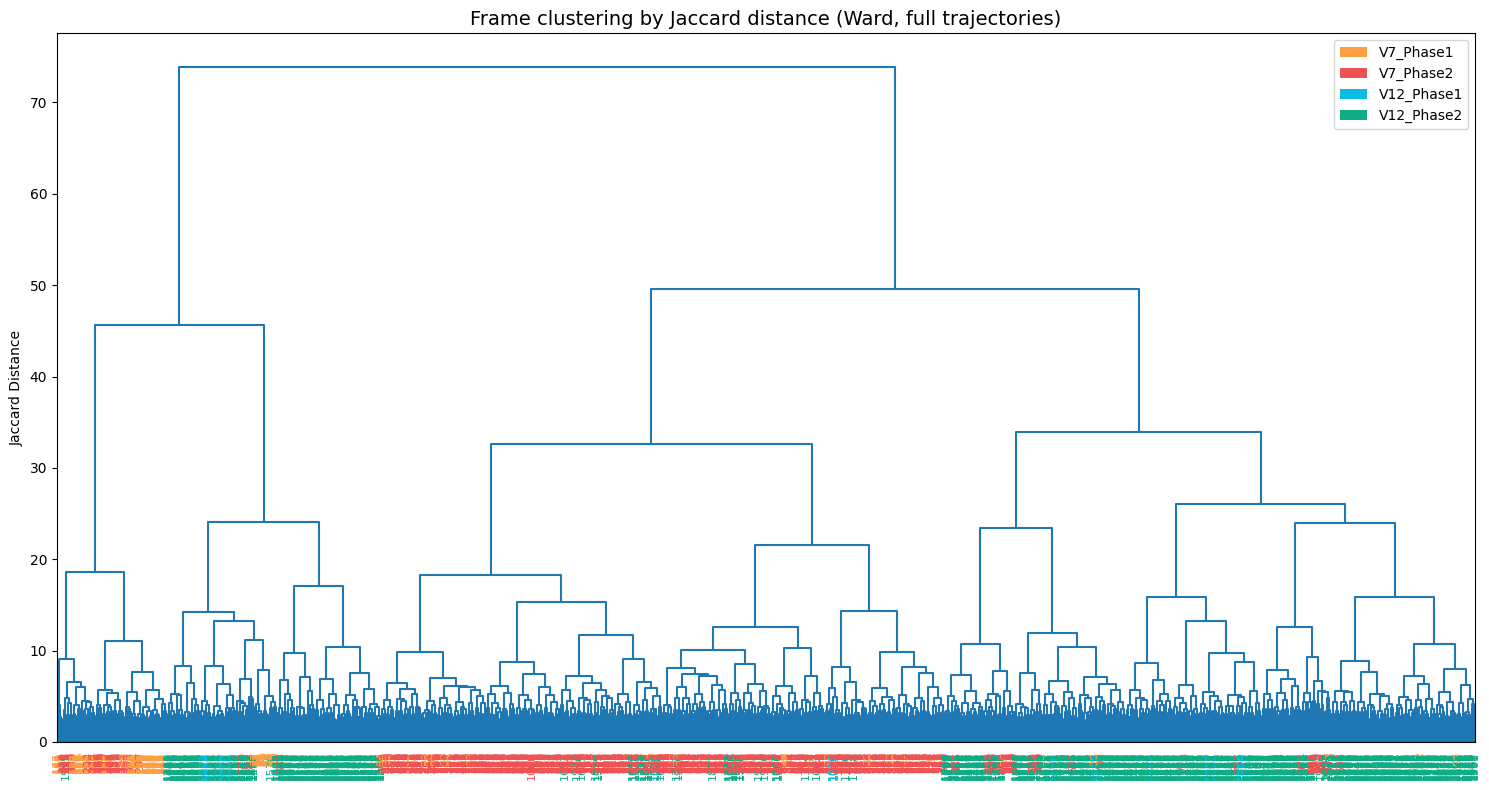

In [14]:
# 10. Hierarchical clustering — full matrix
complete_clustering = linkage(jac_full, method='ward')

fig, ax = plt.subplots(figsize=(15, 8))
dendrogram(complete_clustering, leaf_font_size=8, orientation='top', ax=ax, color_threshold=0)
for lbl in ax.get_xmajorticklabels():
    if lbl.get_text().isdigit():
        lbl.set_color(COLOR_MAP[get_phase_key(int(lbl.get_text()), n_v7)])
ax.legend(handles=[Patch(facecolor=v, label=k) for k, v in COLOR_MAP.items()],
          loc='upper right', fontsize=10)
plt.title('Frame clustering by Jaccard distance (Ward, full trajectories)', fontsize=14)
plt.ylabel('Jaccard Distance')
plt.tight_layout()
plt.show()

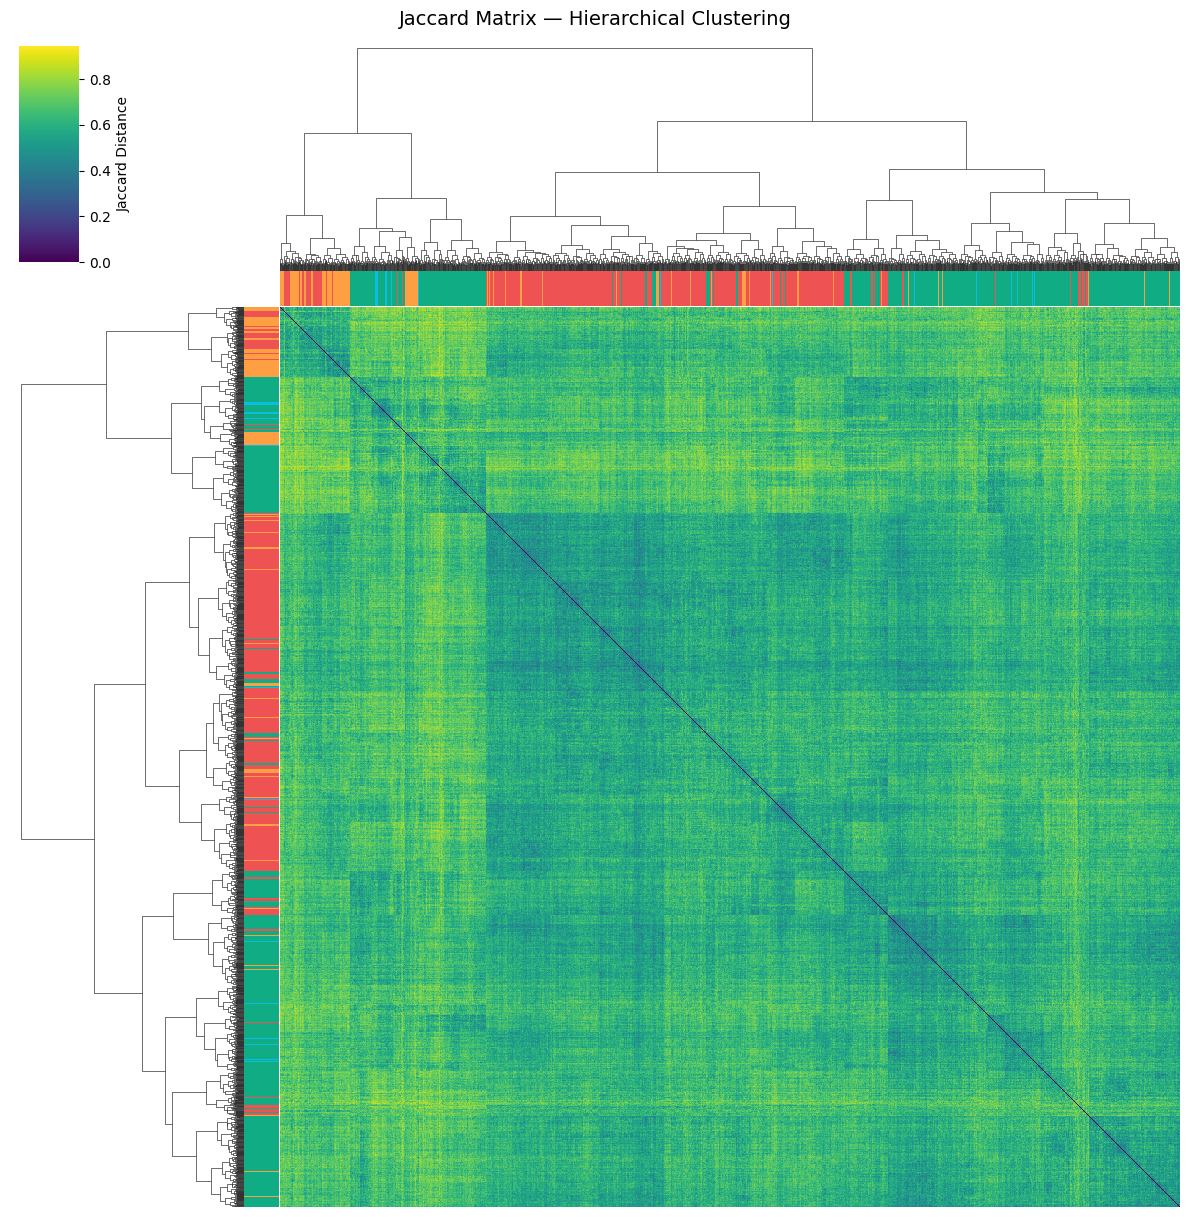

In [10]:
# 11. Clustermap with phase sidebars
meta_colors = [COLOR_MAP[get_phase_key(i, n_v7)] for i in range(len(jac_full))]
g = sns.clustermap(
    jac_full,
    row_linkage=complete_clustering, col_linkage=complete_clustering,
    cmap='viridis', row_colors=meta_colors, col_colors=meta_colors,
    figsize=(12, 12), xticklabels=False, yticklabels=False,
    cbar_kws={'label': 'Jaccard Distance'}
)
g.fig.suptitle('Jaccard Matrix — Hierarchical Clustering', fontsize=14, y=1.01)
plt.show()

/tmp/ipykernel_14072/625436658.py:9: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  clust_ts = linkage(sub_matrix, method='ward')


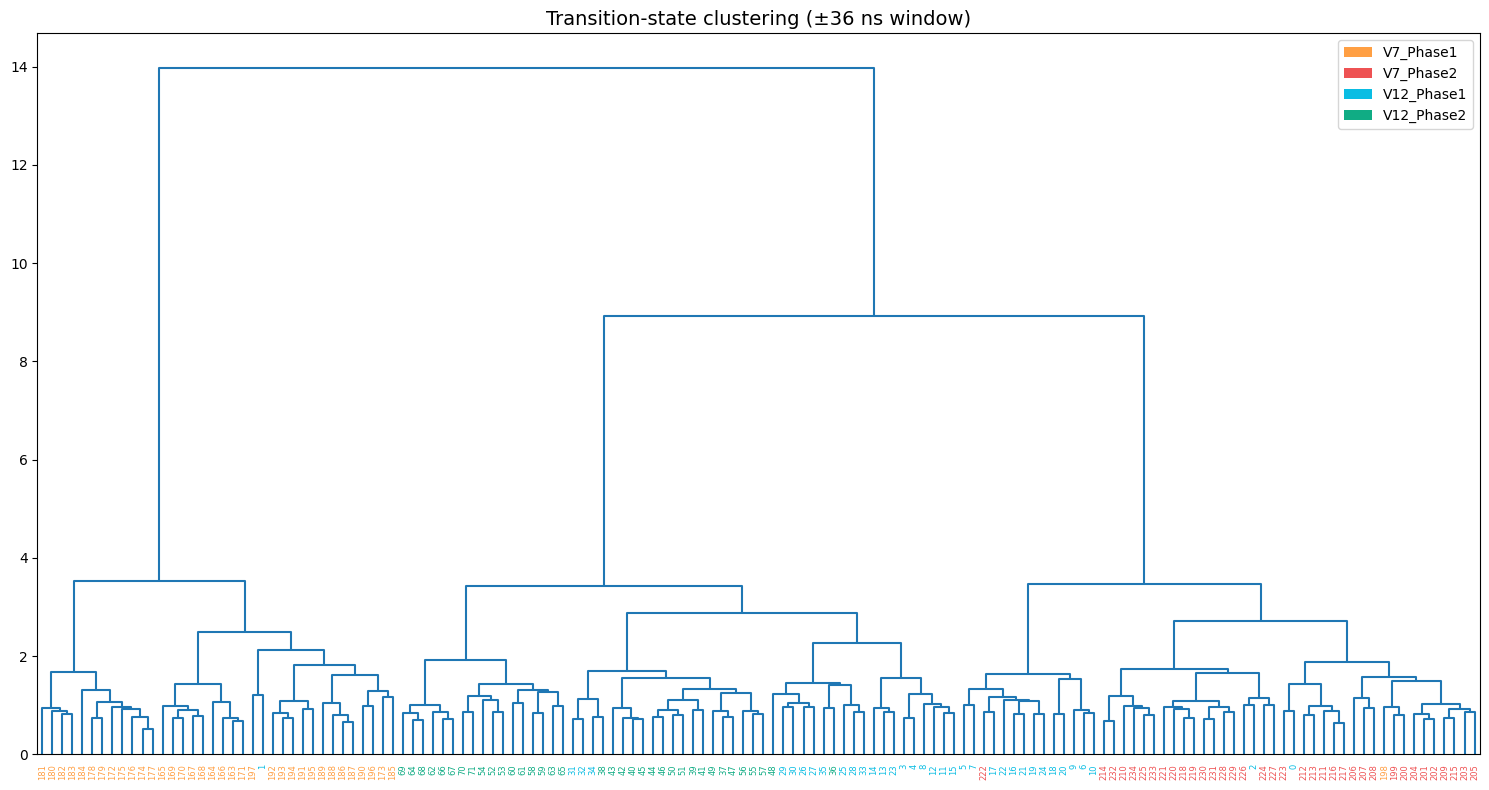

In [13]:
# 12. Transition-state window sub-matrix
v7_transition_idx  = np.arange(PHASE_LIMITS['V7']  - 35, PHASE_LIMITS['V7']  + 37)
v12_transition_idx = np.arange(n_v7 + PHASE_LIMITS['V12'] - 35,
                                n_v7 + PHASE_LIMITS['V12'] + 37)
target_indices    = np.concatenate([v7_transition_idx, v12_transition_idx])
sub_matrix        = jac_full.iloc[target_indices, target_indices]
true_abs_lookup   = list(sub_matrix.index)

clust_ts = linkage(sub_matrix, method='ward')

fig, ax = plt.subplots(figsize=(15, 8))
dendrogram(clust_ts, leaf_font_size=6, orientation='top', ax=ax, color_threshold=0)
xlbls = ax.get_xmajorticklabels()
for lbl in xlbls:
    if lbl.get_text().isdigit():
        abs_idx = true_abs_lookup[int(lbl.get_text())]
        lbl.set_color(COLOR_MAP[get_phase_key(abs_idx, n_v7)])
        local = abs_idx if abs_idx < n_v7 else abs_idx - n_v7
        lbl.set_text(str(local))
ax.set_xticklabels(xlbls)
ax.legend(handles=[Patch(facecolor=v, label=k) for k, v in COLOR_MAP.items()],
          loc='upper right', fontsize=10)
plt.title('Transition-state clustering (±36 ns window)', fontsize=14)
plt.tight_layout()
plt.show()
sub_matrix.to_csv(os.path.join(OUTPUT_DIR, 'jaccard_transition_window.csv'), index=False)

--- Test set evaluation ---
              precision    recall  f1-score   support

     Phase 1       0.72      0.55      0.63        47
     Phase 2       0.94      0.97      0.96       354

    accuracy                           0.92       401
   macro avg       0.83      0.76      0.79       401
weighted avg       0.92      0.92      0.92       401



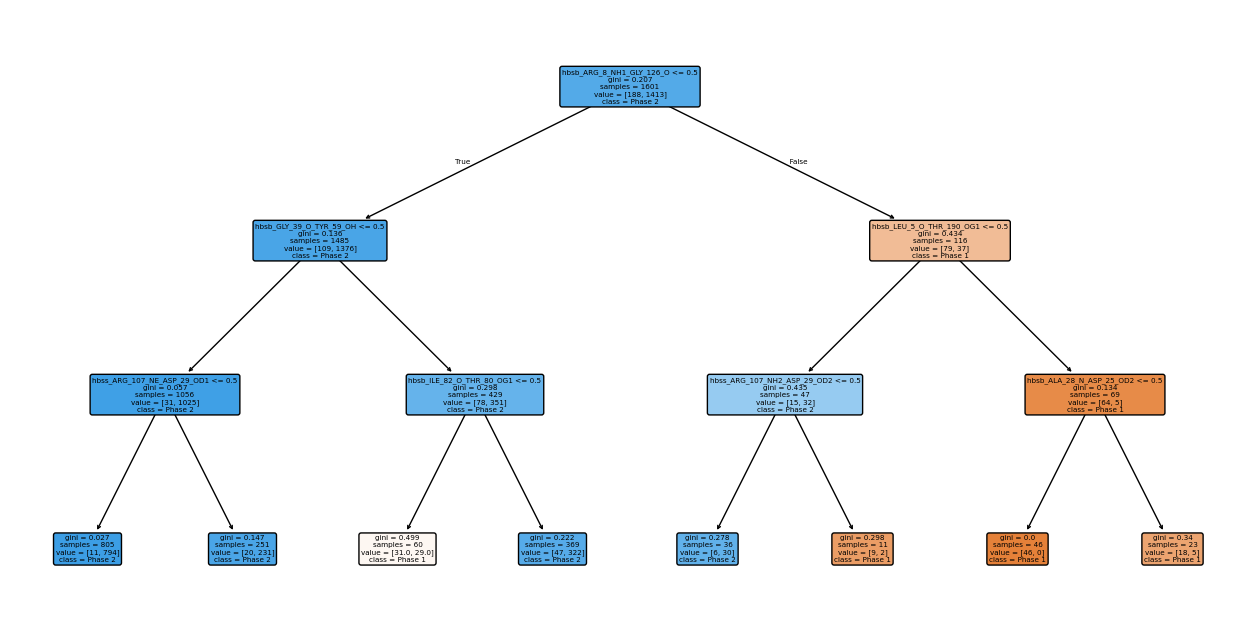

In [20]:
# 13. Decision Tree classifier
V12_df['Phase'] = ['Phase 1' if f <= PHASE_LIMITS['V12'] else 'Phase 2' for f in V12_df.index]
V7_df['Phase']  = ['Phase 1' if f <= PHASE_LIMITS['V7']  else 'Phase 2' for f in V7_df.index]

df_clf = pd.concat([V7_df, V12_df], ignore_index=True)
X_clf  = df_clf.drop(columns=['Phase'])
y_clf  = df_clf['Phase'].tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X_clf, y_clf, test_size=0.2, stratify=y_clf, random_state=1)
clf = DecisionTreeClassifier(max_depth=3)
clf.fit(X_train, y_train)

print('--- Test set evaluation ---')
print(classification_report(y_test, clf.predict(X_test)))

fig, ax = plt.subplots(figsize=(16, 8))
plot_tree(clf, feature_names=X_clf.columns.tolist(),
          class_names=clf.classes_.tolist(),
          filled=True, rounded=True, ax=ax)
fig.savefig(os.path.join(OUTPUT_DIR, 'decision_tree_interactions.png'), dpi=150, bbox_inches='tight')
plt.show()